In [502]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📌 Extracción

Importar los datos de la API de Telecom X. Estos datos están disponibles en formato JSON y contienen información esencial sobre los clientes, incluyendo datos demográficos, tipo de servicio contratado y estado de evasión.

In [431]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [432]:
df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

## Conocer el conjunto de datos

Comprender la estructura del dataset y el significado de sus columnas. Esta etapa te ayudará a identificar qué variables son más relevantes para el análisis de evasión de clientes.

In [433]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [434]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


## Comprobación de incoherencias en los datos

Verificar si hay problemas en los datos que puedan afectar el análisis.

In [435]:
columnas = list(df.columns)
columnas

['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

In [436]:
for col in columnas[2:]:
    df = pd.concat([df.drop(columns=[col]), df[col].apply(pd.Series)], axis=1)
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,"{'Monthly': 55.15, 'Total': '742.9'}"
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 85.1, 'Total': '1873.7'}"
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,"{'Monthly': 50.3, 'Total': '92.75'}"
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,"{'Monthly': 67.85, 'Total': '4627.65'}"


In [437]:
df = pd.concat([df.drop(columns=['Charges']), df['Charges'].apply(pd.Series)], axis=1)
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [438]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [439]:
columnas = list(df.columns)

In [440]:
for col in columnas[1:19]:
  print(f'{col}: {df[col].unique()}')

Churn: ['No' 'Yes' '']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['Yes' 'No' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


## Manejo de inconsistencias

Se ha identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarse de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

In [441]:
df['Churn'].dtype == 'O'

True

In [442]:
df['Churn'].replace('', 'No', inplace=True)

/tmp/ipykernel_890/4283815642.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Churn'].replace('', 'No', inplace=True)


In [443]:
df['Total'].replace(' ', '0', inplace=True)

/tmp/ipykernel_890/2689194049.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total'].replace(' ', '0', inplace=True)


In [444]:
for col in columnas[1:19]:
  if df[col].dtype == 'O':
    df[col] = df[col].str.replace('No phone service','No')
    df[col] = df[col].str.replace('No internet service','No')
  else:
    continue

In [445]:
for col in columnas[1:19]:
  if set(df[col].unique()) == {'Yes', 'No'}:
    df[col] = df[col].str.replace('Yes','1')
    df[col] = df[col].str.replace('No','0')
  else:
    continue

In [446]:
for col in columnas[1:19]:
  print(f'{col}: {df[col].unique()}')

Churn: ['0' '1']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['1' '0']
Dependents: ['1' '0']
tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
PhoneService: ['1' '0']
MultipleLines: ['0' '1']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['0' '1']
OnlineBackup: ['1' '0']
DeviceProtection: ['0' '1']
TechSupport: ['1' '0']
StreamingTV: ['1' '0']
StreamingMovies: ['0' '1']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['1' '0']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [447]:
for col in columnas[1:19]:
  if set(df[col].unique()) == {'0', '1'}:
    df[col] = df[col].astype(np.int8)
  else:
    continue
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int8   
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int8   
 5   Dependents        7267 non-null   int8   
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int8   
 8   MultipleLines     7267 non-null   int8   
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   int8   
 11  OnlineBackup      7267 non-null   int8   
 12  DeviceProtection  7267 non-null   int8   
 13  TechSupport       7267 non-null   int8   
 14  StreamingTV       7267 non-null   int8   
 15  StreamingMovies   7267 non-null   int8   
 16  Contract          7267 non-null   object 


In [448]:
for col in columnas[1:19]:
  print(f'{col}: {df[col].unique()}')

Churn: [0 1]
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [1 0]
tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
PhoneService: [1 0]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [1 0]
StreamingTV: [1 0]
StreamingMovies: [0 1]
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [449]:
df.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
5407,7396-VJUZB,0,Male,0,1,1,4,1,0,DSL,...,0,0,0,0,0,Month-to-month,0,Mailed check,45.25,155.35
5909,8069-YQQAJ,0,Male,0,0,0,14,0,0,DSL,...,1,0,0,0,0,Month-to-month,1,Mailed check,31.10,419.7
3254,4541-RMRLG,1,Male,0,0,0,7,1,0,No,...,0,0,0,0,0,Month-to-month,0,Electronic check,19.25,112.3
2894,4012-YCFAI,0,Male,0,1,0,60,1,0,DSL,...,1,0,1,0,0,Two year,1,Mailed check,61.35,3766.2
2224,3097-NNSPB,1,Female,0,0,0,2,1,0,DSL,...,1,0,0,0,0,Month-to-month,1,Credit card (automatic),49.05,91.1


In [450]:
df['CuentasDiarias'] = df['Monthly']/30

In [451]:
df.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,CuentasDiarias
7022,9667-TKTVZ,0,Female,0,0,0,2,1,1,DSL,...,0,1,0,0,Month-to-month,1,Mailed check,54.35,117.05,1.811667
7012,9650-VBUOG,0,Male,0,1,1,38,1,1,No,...,0,0,0,0,Two year,0,Credit card (automatic),25.05,963.95,0.835000
4359,5981-ZVXOT,0,Female,1,0,0,35,1,1,Fiber optic,...,1,0,1,1,One year,1,Electronic check,108.35,3726.15,3.611667
1298,1866-NXPSP,0,Female,0,0,0,36,1,0,DSL,...,1,1,0,1,One year,1,Mailed check,75.55,2680.15,2.518333
5078,6937-GCDGQ,0,Male,0,1,1,19,1,0,DSL,...,0,0,0,0,One year,1,Bank transfer (automatic),48.95,955.6,1.631667


In [452]:
df['Total'] = df['Total'].astype(np.float64)
df['Total'] = df['Total'].astype(np.float64)

#📊 Carga y análisis

## Análisis Descriptivo

Para comenzar, se realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [453]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Monthly,Total,CuentasDiarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157337
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Distribución de evasión

El objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes.

In [454]:
df_churn = df[['customerID','Churn']].groupby('Churn').count()
df_churn

,customerID
Churn,
0,5398
1,1869


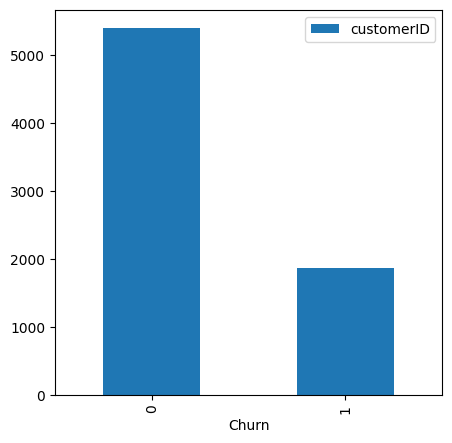

In [455]:
df_churn.plot(kind='bar', figsize=(5,5));

In [456]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int8   
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int8   
 5   Dependents        7267 non-null   int8   
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int8   
 8   MultipleLines     7267 non-null   int8   
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   int8   
 11  OnlineBackup      7267 non-null   int8   
 12  DeviceProtection  7267 non-null   int8   
 13  TechSupport       7267 non-null   int8   
 14  StreamingTV       7267 non-null   int8   
 15  StreamingMovies   7267 non-null   int8   
 16  Contract          7267 non-null   object 


## Recuento de evasión por variables  categóricas

exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago para evelar patrones interesantes.

In [457]:
df_gender = df[['customerID','Churn','gender']].groupby(['Churn','gender']).count()
df_gender

customerID
Churn gender            
0     Female        2653
      Male          2745
1     Female         939
      Male           930

In [458]:
df_Contract = df[['customerID','Churn','Contract']].groupby(['Churn','Contract']).count()
df_Contract

customerID
Churn Contract                  
0     Month-to-month        2350
      One year              1353
      Two year              1695
1     Month-to-month        1655
      One year               166
      Two year                48

In [459]:
df_PaymentMethod = df[['customerID','Churn','PaymentMethod']].groupby(['Churn','PaymentMethod']).count()
df_PaymentMethod

customerID
Churn PaymentMethod                        
0     Bank transfer (automatic)        1331
      Credit card (automatic)          1336
      Electronic check                 1374
      Mailed check                     1357
1     Bank transfer (automatic)         258
      Credit card (automatic)           232
      Electronic check                 1071
      Mailed check                      308

## Conteo de evasión por variables numéricas

Se explorara cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

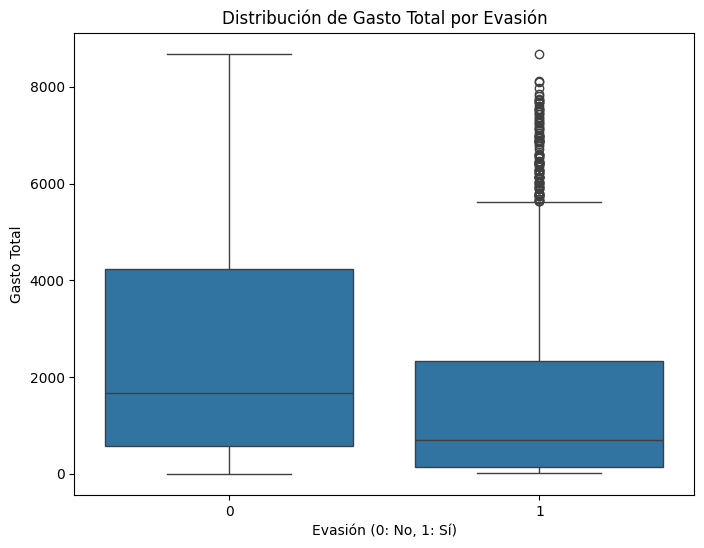

In [503]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Total', data=df)
plt.title('Distribución de Gasto Total por Evasión')
plt.xlabel('Evasión (0: No, 1: Sí)')
plt.ylabel('Gasto Total')
plt.show()

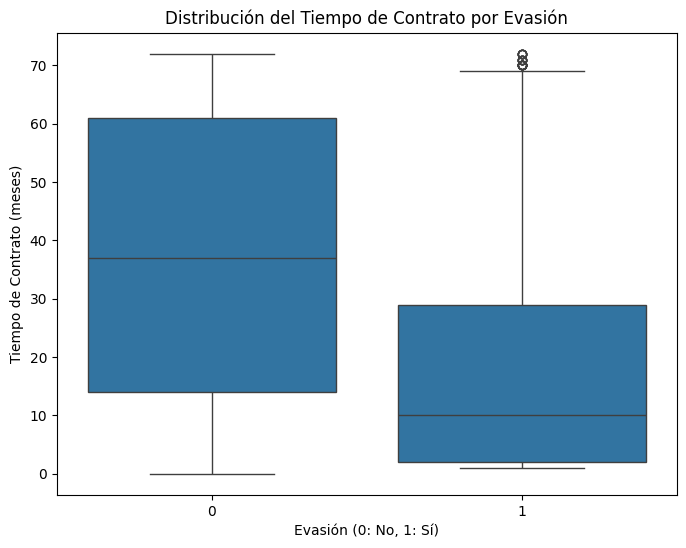

In [504]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Distribución del Tiempo de Contrato por Evasión')
plt.xlabel('Evasión (0: No, 1: Sí)')
plt.ylabel('Tiempo de Contrato (meses)')
plt.show()

#📄Informe final

## Introducción
Este informe tiene como objetivo analizar los datos de clientes de Telecom X para comprender los factores que contribuyen a la evasión de clientes (Churn). La evasión de clientes es un problema crítico para las empresas de telecomunicaciones, ya que la retención de clientes existentes es a menudo más rentable que la adquisición de nuevos. Al identificar los patrones y las causas subyacentes de la evasión, podemos desarrollar estrategias más efectivas para mejorar la satisfacción del cliente y reducir la tasa de abandono.

## Limpieza y Tratamiento de Datos

Los datos fueron importados inicialmente desde una URL JSON a un DataFrame de pandas.

Para estructurar los datos anidados, se realizaron los siguientes pasos:
- Las columnas que contenían diccionarios ('customer', 'phone', 'internet', 'account') fueron expandidas. Esto se logró aplicando `pd.Series` a cada una de estas columnas y concatenando los resultados con el DataFrame original, eliminando las columnas de diccionario iniciales. Luego, la columna 'Charges', que también contenía un diccionario, fue expandida de manera similar.

En cuanto al manejo de valores nulos o inconsistentes y la conversión de tipos de datos:
- La columna 'Churn' presentaba valores vacíos, los cuales fueron reemplazados por 'No'.
- La columna 'Total' contenía espacios en blanco, que se trataron como '0' y posteriormente se convirtió a tipo numérico (`float64`).
- Se estandarizaron los valores en varias columnas: 'No phone service' y 'No internet service' fueron reemplazados por 'No'.
- Para facilitar el análisis, los valores categóricos 'Yes' y 'No' en las columnas relevantes (como 'Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling') se convirtieron a valores numéricos '1' y '0' respectivamente, y luego se les asignó el tipo de dato `int8`.
- Finalmente, se creó una nueva columna llamada 'CuentasDiarias' calculando el gasto mensual (`Monthly`) dividido por 30 para obtener un promedio diario.

## Análisis Exploratorio de Datos

### Resumen de los Análisis Exploratorios

Se ha realizado un análisis exploratorio de datos para comprender la estructura del conjunto de datos `df` y las relaciones entre las variables, especialmente con respecto a la variable 'Churn' (evasión de clientes).

#### Estadísticas Descriptivas:
- **Churn**: La media de `Churn` (0.257) indica que aproximadamente el 25.7% de los clientes han evadido, lo que sugiere un desequilibrio de clases. Esto es coherente con el análisis de `df_churn`.
- **Tenure**: La tenencia promedio de los clientes es de aproximadamente 32.3 meses, con una desviación estándar considerable (24.5 meses), indicando una amplia variabilidad en el tiempo que los clientes permanecen con el servicio. Hay clientes con 0 meses de antigüedad, lo cual podría indicar un error o un nuevo registro sin cargos aún.
- **Monthly Charges**: Los cargos mensuales (`Monthly`) tienen un promedio de 64.72, con un rango que va desde 18.25 hasta 118.75.
- **Total Charges**: Los cargos totales (`Total`) promedian 2277.18, pero con una desviación estándar alta (2268.65), mostrando también una gran dispersión. El valor mínimo de 0.00 en 'Total' para algunos clientes podría estar relacionado con la 'tenure' de 0 meses.

#### Distribución de 'Churn':
- **Conteo**: Los datos muestran que hay 5398 clientes que 'No' han evadido (Churn = 0) y 1869 clientes que 'Sí' han evadido (Churn = 1).
- **Patrón**: El gráfico de barras de `df_churn` visualiza claramente este desequilibrio, confirmando que la mayoría de los clientes no han evadido, lo cual es una característica importante a considerar para el modelado.

#### Relación entre 'Churn' y 'gender':
- **Conteo**: La distribución de `Churn` por género es bastante equilibrada. Para los clientes que no evaden, hay 2653 mujeres y 2745 hombres. Para los que sí evaden, hay 939 mujeres y 930 hombres.
- **Patrón**: No se observa una diferencia significativa en la tasa de evasión entre hombres y mujeres, lo que sugiere que el género no es un factor determinante directo en la decisión de evasión.

#### Relación entre 'Churn' y 'Contract':
- **Conteo**: La mayoría de los clientes que evaden (1655) tienen contratos de 'Month-to-month' (mes a mes). En contraste, solo 166 con contrato de 'One year' y 48 con 'Two year' evaden.
- **Patrón**: Los clientes con contratos de mes a mes son significativamente más propensos a evadir que aquellos con contratos a más largo plazo (uno o dos años). Esto es un hallazgo clave, ya que los contratos a largo plazo parecen ser un factor protector contra la evasión.

#### Relación entre 'Churn' y 'PaymentMethod' :
- **Conteo**: El método de pago 'Electronic check' (1071) es el que tiene la mayor cantidad de clientes que evaden, en comparación con otros métodos como 'Bank transfer' (258), 'Credit card' (232) o 'Mailed check' (308).
- **Patrón**: Existe una clara correlación entre el método de pago 'Electronic check' y la evasión de clientes. Los clientes que utilizan este método de pago son más propensos a evadir.

#### Distribución de 'Total' por 'Churn':
- **Visualización**: El boxplot de 'Total' por 'Churn' muestra que los clientes que evaden tienen un gasto total generalmente más bajo y con menor dispersión en comparación con los clientes que no evaden. Los clientes que no evaden muestran una distribución más amplia de gasto total, con valores mucho más altos.
- **Patrón**: Los clientes con gastos totales más bajos son más propensos a evadir el servicio. Esto podría indicar que los clientes con un menor compromiso financiero o menos uso del servicio son los primeros en irse.

#### Distribución de 'tenure' por 'Churn':
- **Visualización**: El boxplot de 'tenure' por 'Churn' revela que los clientes que evaden tienen una tenencia significativamente más corta que los clientes que no evaden. La mediana de 'tenure' para los clientes que evaden es mucho más baja.
- **Patrón**: Los clientes con un tiempo de permanencia más corto son más propensos a evadir, lo que sugiere que la lealtad del cliente aumenta con la antigüedad. La evasión es más común en las primeras etapas de la relación con el cliente.

## Conclusiones y Recomendaciones

### Principales Hallazgos del Análisis:

*   **Impacto del Tipo de Contrato**: Se observa una clara correlación entre el tipo de contrato y la evasión. Los clientes con contratos mes a mes tienen una tasa de evasión considerablemente más alta (1655 de 2350 clientes que evaden tienen este tipo de contrato) en comparación con aquellos que tienen contratos de uno o dos años (solo 166 y 48, respectivamente, evaden). Esto sugiere que la flexibilidad de los contratos mensuales facilita la decisión de abandonar el servicio.
*   **Asociación del Método de Pago**: El método de pago Electronic check se asocia con una tasa de evasión notablemente superior (1071 clientes que evaden usan este método) en comparación con otros métodos. Esto podría indicar una menor lealtad o satisfacción entre los usuarios de este método de pago.
*   **Tiempo de Contrato (Tenure) y Evasión**: Existe una fuerte relación inversa entre el tenure (tiempo que el cliente ha permanecido con la compañía) y la evasión. Los clientes con un tenure más corto (`9`, `4`, `13`, `3` meses y hasta `1` mes) son mucho más propensos a evadir, mientras que los clientes a largo plazo (`72`, `71`, `67` meses) muestran una tasa de evasión mucho menor. Esto subraya la importancia de la retención de clientes desde las primeras etapas.

### Cómo estos datos pueden ayudar a reducir la evasión de clientes:

Estos hallazgos proporcionan una base sólida para desarrollar estrategias de retención de clientes:

1.  **Incentivar Contratos a Largo Plazo**: Dado que los contratos Month-to-month tienen una alta tasa de evasión, la compañía podría ofrecer descuentos o beneficios adicionales para incentivar a los clientes a optar por contratos de One year o Two year. Esto podría incluir mejores tarifas, servicios adicionales gratuitos o actualizaciones de hardware.

2.  **Enfocarse en la Retención Temprana**: Es crucial establecer programas de onboarding robustos y estrategias de compromiso para los clientes durante sus primeros meses. Esto podría incluir seguimiento proactivo, ofertas especiales para nuevos clientes, o soporte técnico mejorado para asegurar una experiencia positiva desde el principio. Una estrategia efectiva podría ser identificar clientes con tenure bajo y altos gastos mensuales, ya que estos tienen un gran potencial de churn y un alto valor de vida útil.